# FaceDetector Processing

---

Tahapan ini mencakup pengambilan, pemrosesan dan evaluasi untuk skenario tugas dan istirahat
- Mengambil data dari file npy
- Melakukan pre-processing pada sinyal rPPG dan PPG
- Melakukan extraksi HR dan HRV (SDNN dan RMSSD)
- Evaluasi MAE, RMSE dan PC

In [1]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import numpy as np


In [2]:
@dataclass
class SignalData:
    subject: str
    task: str
    method: str  # PPG / POS / LGI / GREEN / CHROM / OMIT
    raw: np.ndarray
    fs: int
    preprocessed: np.ndarray = None


## Preprocessing & Signal Extraction

### Define the processing method (Preprocess, Ekstraksi HR / HRV Metrik Pipeline)
---

In [3]:
def preprocess_rppg(rppg_signal, fs_rppg=35, fs_ppg=64):
    # Target: exactly 180 seconds at 64 Hz = 11520 samples
    target_duration = 180.0  # seconds
    target_samples = 11520  # Exact target
    
    # Calculate current duration
    current_duration = len(rppg_signal) / fs_rppg
    print(f"Original samples: {len(rppg_signal)}, Current duration: {current_duration:.2f}s")
    
    # Trim to exactly 180 seconds if longer
    if current_duration > target_duration:
        samples_to_keep = int(target_duration * fs_rppg)  # 180 * 35 = 6300 samples
        rppg_trimmed = rppg_signal[:samples_to_keep]
        print(f"Trimmed to {len(rppg_trimmed)} samples ({len(rppg_trimmed)/fs_rppg:.2f}s)")
    else:
        rppg_trimmed = rppg_signal
        print(f"No trimming needed, using {len(rppg_trimmed)} samples")
    
    # Cubic spline interpolation with EXACT target samples
    duration_trimmed = len(rppg_trimmed) / fs_rppg
    t_old = np.arange(len(rppg_trimmed)) / fs_rppg
    t_new = np.linspace(0, duration_trimmed, target_samples, endpoint=False)  # endpoint=False is KEY
    cs = scipy.interpolate.CubicSpline(t_old, rppg_trimmed)
    rppg_up = cs(t_new)
    
    print(f"After interpolation: {len(rppg_up)} samples (target: {target_samples})")
    
    # Bandpass filter at new rate
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    rppg_filtered = scipy.signal.filtfilt(b, a, rppg_up)
    
    # Normalize
    rppg_filtered = (rppg_filtered - np.mean(rppg_filtered)) / np.std(rppg_filtered)
    
    # Final verification
    print(f"Final output: {len(rppg_filtered)} samples")
    assert len(rppg_filtered) == target_samples, f"Length mismatch: got {len(rppg_filtered)}, expected {target_samples}"
    
    return rppg_filtered

In [4]:
def preprocess_ppg(ppg_signal, fs_ppg=64):

    # Bandpass filter the PPG signal
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    ppg_filtered = scipy.signal.filtfilt(b, a, ppg_signal)

    # Normalize the signal
    ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / np.std(ppg_filtered)

    return ppg_filtered


Main Methods

---

Opening the npy files for FaceDetector

In [5]:
root_path = "../dataset_numpy"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T1", "T3"] # Rest, Task

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

all_signals = []

for subject in subjects:
    for task in tasks:
        # --- Ground truth PPG ---
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        gt_signal = preprocess_ppg(gt_data, fs_ppg=sample_rate_gt)

        all_signals.append(
            SignalData(
                subject=subject,
                task=task,
                method="PPG",
                raw=gt_data,
                fs=sample_rate_gt,
                preprocessed=gt_signal
            )
        )

        # --- rPPG methods ---
        for method in ["POS", "LGI", "OMIT", "GREEN", "CHROM"]:
            file_path = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_{method}_rppg.npy")
            rppg_raw = np.load(file_path)

            rppg_preproc = preprocess_rppg(rppg_raw,
                                           fs_rppg=sample_rate_video,
                                           fs_ppg=sample_rate_gt)

            all_signals.append(
                SignalData(
                    subject=subject,
                    task=task,
                    method=method,
                    raw=rppg_raw,
                    fs=sample_rate_video,
                    preprocessed=rppg_preproc
                )
            )

## Sanity check the pipeline for the result
## Expected all methods should have length of 11520 (64 Hz * 180 sec = 11520 samples long)
summary = pd.DataFrame([{
    "Subject": sig.subject,
    "Task": sig.task,
    "Method": sig.method,
    "RawLen": len(sig.raw),
    "PreprocLen": len(sig.preprocessed)
} for sig in all_signals])

print(summary.head(20))


Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325, Current duration: 180.71s
Trimmed to 6300 samples (180.00s)
After interpolation: 11520 samples (target: 11520)
Final output: 11520 samples
Original samples: 6325

Notes:

---

The signal been in the same length and preprocessed

and it's fine to move on to the HR / HRV Extraction

## Evaluasi Performa rPPG
---

Tahapan ini akan mengukur HR / HRV dari rPPG dan PPG

In [6]:
@dataclass
class MetricData:
    subject: str
    task: str
    method: str
    hr: float
    sdnn: float
    rmssd: float


**Formula Perhitungan HR dan HRV**

**Heart Rate (HR):**
$$
HR = \frac{60}{\overline{RR}}
$$
- $\overline{RR}$ = rata-rata interval RR (detik) antar puncak sinyal

**SDNN (Standard Deviation of NN intervals):**
$$
SDNN = \text{std}(RR_{ms})
$$
- $(RR_{ms})$ = interval RR dalam milidetik

**RMSSD (Root Mean Square of Successive Differences):**
$$
RMSSD = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N-1} (RR_{ms,i+1} - RR_{ms,i})^2}
$$
- $(RR_{ms,i})$ = interval RR ke-i dalam milidetik
- $(N)$ = jumlah interval RR valid

**Langkah:**
1. Deteksi puncak sinyal (peak detection)
2. Hitung interval RR antar puncak: $(RR = \frac{\Delta \text{peak}}{fs})$
3. Bersihkan RR di luar rentang 0.3–2.0 detik
4. Konversi RR ke milidetik: $(RR_{ms} = RR \times 1000)$
5. Hitung HR, SDNN, RMSSD dengan rumus

In [7]:
# ## Define the method to compute the metrics
# ## This method will takes any signal (rPPG, PPG) 
# # and it's sampling rate to get the HR and HRv
# def compute_metrics(signal, fs):
#     ## Compute the HR
#     peaks , _ = scipy.signal.find_peaks(signal, prominence=0.5)

#     ## Getting the RR Interval / Jeda Waktu antar Puncak / Beat
#     rr_intervals = np.diff(peaks) / fs  # Convert to unit seconds

#     ## Clean the RR
#     rr = np.asarray(rr_intervals, dtype=float)
#     rr_intervals = rr[( rr >= 0.3 ) & (rr <= 2.0)] # Clean RR interval outside 0.3 - 2.0 seconds

#     ## Calculating the HR
#     hr = int(60 / np.mean(rr_intervals))

#     ## Converting RR interval for milis for HRV analysis
#     rr_intervals_ms = rr_intervals * 1000  # Convert to milliseconds

#     ## Calculating the HRV (SDNN, RMSSD)
#     ## Casting to Int for easier interpretation
#     sdnn = int(np.std(rr_intervals_ms))
#     rmssd = int(np.sqrt(np.mean(np.square(np.diff(rr_intervals_ms)))))

#     return hr, sdnn, rmssd

In [8]:
import numpy as np
import scipy.signal

def compute_metrics(signal, fs, segment_len=25, seg_threshold=0.3):
    
    # 1. Detect peaks
    peaks, _ = scipy.signal.find_peaks(signal, prominence=0.5)
    
    if len(peaks) < 2:
        return np.nan, np.nan, np.nan  # Not enough peaks
    
    # 2. Compute RR intervals (s)
    rr = np.diff(peaks) / fs
    rr = np.asarray(rr, dtype=float)
    
    # 3. Hard physiologic filter
    rr = rr[(rr >= 0.3) & (rr <= 2.0)]
    if len(rr) < 2:
        return np.nan, np.nan, np.nan
    
    # 4. Segment-based ±30% filtering
    clean_rr = []
    num_segments = len(rr) // segment_len
    for i in range(num_segments):
        seg = rr[i*segment_len:(i+1)*segment_len]
        mean_seg = np.mean(seg)
        lower = mean_seg * (1 - seg_threshold)
        upper = mean_seg * (1 + seg_threshold)
        clean_seg = seg[(seg >= lower) & (seg <= upper)]
        clean_rr.extend(clean_seg)
        
    rr_final = np.array(clean_rr)
    if len(rr_final) < 2:
        return np.nan, np.nan, np.nan
    
    # 6. Compute HR
    hr = int(60 / np.mean(rr_final))
    
    # 7. Convert to ms for HRV
    rr_ms = rr_final * 1000
    
    # 8. Compute HRV metrics
    sdnn = int(np.std(rr_ms))
    rmssd = int(np.sqrt(np.mean(np.square(np.diff(rr_ms)))))
    
    return hr, sdnn, rmssd


**Create a Header Template for HR, HRV**

---

Membuat header template agar tabel lebih padat dan bisa memuat banyak informasi, akan ada 3 tabel (HR, SDNN, RMSSD), dikelompokan berdasarkan 
- Tipe skenario
- Metode pengukuran data

In [9]:
arrays = [
    [""] + ["Rest"]*6 + ["Task"]*6,
    ["Subject", "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM",
     "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
]


columns = pd.MultiIndex.from_arrays(arrays)

In [10]:
all_metrics = []

for sig in all_signals:
    hr, sdnn, rmssd = compute_metrics(sig.preprocessed, 64)
    all_metrics.append(MetricData(sig.subject, sig.task, sig.method, hr, sdnn, rmssd))


In [11]:
df_metrics = pd.DataFrame([{
    "Subject": metrics.subject,
    "Task": metrics.task,
    "Method": metrics.method,
    "HR": metrics.hr,
    "SDNN": metrics.sdnn,
    "RMSSD": metrics.rmssd
} for metrics in all_metrics])


#### Ekstraksi HR

---

In [12]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_hr = pd.DataFrame(rows, columns=columns)
df_hr

Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   97   95    96   96   96    96   81   97    70   97   95    97
1      s42   70   70    69   69   69    71   86   87    70   70   74    76
2      s43   95   95    88   94   94    94   88   81    63   82   74    86
3      s44   62   65    61   63   63    63   65   63    60   64   65    63
4      s45   77   76    73   74   74    75   83   76    60   65   65    74
5      s46   74   74    74   74   74    74   90   86    78   88   88    88
6      s47   77   76    75   76   76    76   83   75    67   83   79    84
7      s48   68   71    70   71   71    71   81   73    69   74   72    71
8      s49  101  101   101  101  101   101   72   76    60   73   72    74
9      s50  103  100    90  101  101   101  105  100    67  101  101   102
10     s51   62   62    62   62   62    62   73   73    57   71   71    70
11     s52   78   89    85   89   89    90   78   84    68   85   85    84
12     s53   64   85    84   85   85    85   66   77    67   72   72    73
13     s54   91   92    63   92   92    93   93   89    69   85   84    87
14     s55   93   59    52   56   57    54   87   85    67   82   82    87
15     s56   73   70    69   76   73    73   80   74    55   80   80    92

## Observasi Fisiologis HR
We use how does the task induced can affect the HR

In [13]:
# build grouped stats
grouped = df_metrics.groupby(['Task','Method']).agg({
    'HR':   ['mean','std'],
    'SDNN': ['mean','std'],
    'RMSSD':['mean','std']
})
# flatten column names
grouped.columns = [f"{m}_{stat}" for m,stat in grouped.columns]
grouped = grouped.reset_index()

# build formatted table: MultiIndex rows (Metric, Method) and columns per Task with "mean ± sd"
metrics = ['HR','SDNN','RMSSD']
methods = grouped['Method'].unique()
tasks = grouped['Task'].unique()

rows = []
for metric in metrics:
    for method in methods:
        row = {'Metric': metric, 'Method': method}
        for task in tasks:
            sel = grouped[(grouped['Task']==task) & (grouped['Method']==method)]
            if not sel.empty:
                mean = sel[f'{metric}_mean'].values[0]
                sd   = sel[f'{metric}_std'].values[0]
                row[task] = f"{mean:.2f} ± {sd:.2f}"
            else:
                row[task] = None
        rows.append(row)

df_summary = pd.DataFrame(rows).set_index(['Metric','Method'])
df_summary

T1              T3
Metric Method                                
HR     CHROM    79.94 ± 14.62   81.75 ± 10.66
       GREEN    75.75 ± 13.72    65.44 ± 5.86
       LGI      79.94 ± 14.33   79.50 ± 10.55
       OMIT     79.81 ± 14.29   78.69 ± 10.14
       POS      80.00 ± 13.86    81.00 ± 9.56
       PPG      80.31 ± 14.21   81.94 ± 10.14
SDNN   CHROM   110.44 ± 42.78  127.06 ± 30.16
       GREEN   115.62 ± 43.92  164.06 ± 22.68
       LGI      99.00 ± 35.81  130.06 ± 27.71
       OMIT    101.94 ± 42.56  136.81 ± 28.68
       POS     103.81 ± 31.06  137.06 ± 24.79
       PPG      87.19 ± 48.24  112.69 ± 36.22
RMSSD  CHROM   144.56 ± 53.97  166.62 ± 32.01
       GREEN   138.81 ± 57.83  209.00 ± 24.83
       LGI     121.75 ± 46.93  163.81 ± 28.65
       OMIT    120.38 ± 43.79  171.62 ± 29.46
       POS     138.75 ± 44.74  169.25 ± 21.66
       PPG      90.25 ± 54.80  139.00 ± 46.32

#### Evaluasi HR (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai HR antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran HR dari rPPG dan PPG.

In [14]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_hr[(cond, "GT")]  # ground truth for this condition
    for method in methods:
        row=[method]
        pred = df_hr[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_hr = pd.DataFrame(eval_results)
print("HR (satuan: BPM)")
eval_df_hr

HR (satuan: BPM)


,Condition,Method,MAE,RMSE,PC
0,Rest,POS,5.1875,10.491068,0.702384
1,Rest,GREEN,8.1875,14.086785,0.514549
2,Rest,LGI,5.3750,11.090537,0.678106
3,Rest,OMIT,5.1250,10.857025,0.691077
4,Rest,CHROM,5.3750,11.543396,0.658543
5,Task,POS,5.6875,6.878408,0.746065
6,Task,GREEN,16.6250,18.784967,0.430035
7,Task,LGI,6.1875,8.370335,0.680821
8,Task,OMIT,6.6250,8.558621,0.674813
9,Task,CHROM,5.6875,7.232738,0.743263


**Visualisasi Hasil MAE, RMSE dan PC**

---

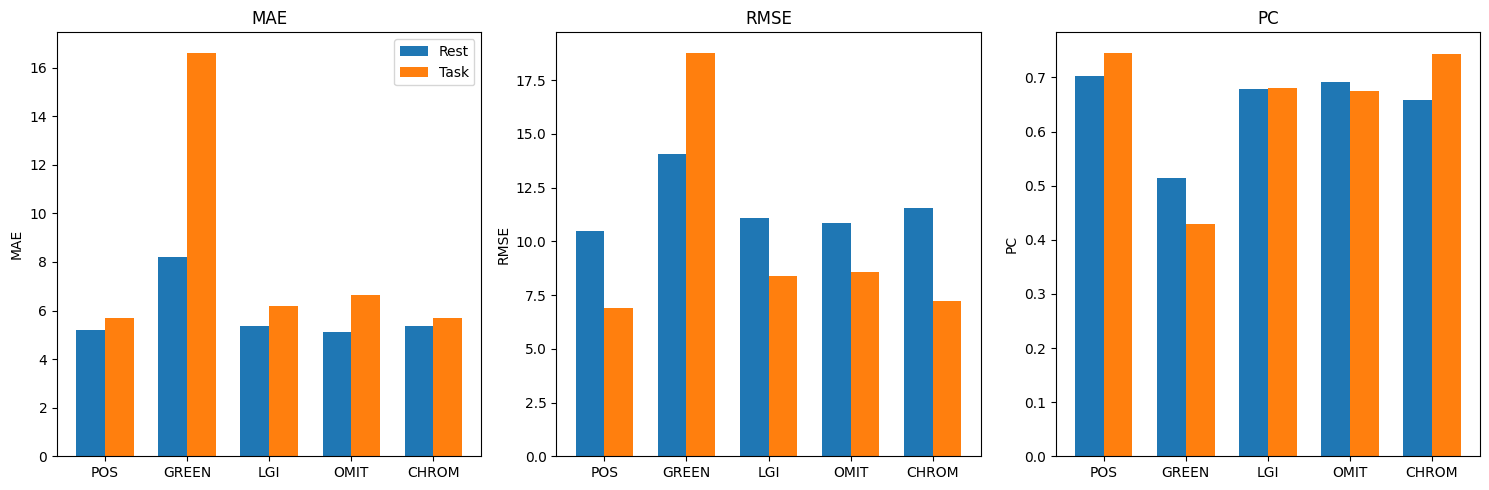

In [15]:
metrics = ["MAE", "RMSE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_hr[eval_df_hr["Condition"]=="Rest"][metric]
    task_vals = eval_df_hr[eval_df_hr["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 4.4375     | 7.335700    | 0.890876  | 6.8125     | 9.775607    | 0.667658  |
| GREEN  | 7.8750     |10.191909    | 0.698441  |10.2500     |13.697628    | 0.250453  |
| LGI    | 3.6875     | 6.562202    | 0.897551  | 8.1875     |13.695346    | 0.321868  |
| OMIT   | 3.6875     | 6.562202    | 0.897551  | 8.1875     |13.736357    | 0.322018  |
| CHROM  | 4.1250     | 6.698881    | 0.908825  | 7.1875     | 9.450529    | 0.600982  |

**Observation**

---

- Pada kondisi istirahat, rPPG dapat mengukur HR (detak jantung) dengan cukup stabil dan konsistensi yang tinggi terhadap hasil HR dari PPG, dengan nilai MAE < 5 (stabilitas) dan PC > 0.8 (konsistensi) baik.
- Sebaliknya, pada tugas mental, pengukuran HR (detak jantung) relatif kurang stabil dengan error yang meningkat (MAE dan RMSE lebih tinggi), dan korelasi (PC) yang menurun, menandakan reliabilitas rPPG berkurang dalam mengukur detak jantung (HR), karena pada tugas mental, tidak sepenuhnya subjek diam, penurunan performa ini kemungkinan disebabkan oleh gerakan wajah, ekspresi dan pencahayaan yang lebih bervariasi dibandingkan saat kondisi istirahat, dimana subjek relatif diam. 
- Secara umum, dalam studi biomedis, MAE < 5 bpm dan RMSE < 8 bpm dianggap cukup baik untuk estimasi HR dari video, serta PC > 0.8 (baik) dan > 0.6 (moderat) [[0]](https://biomedical-engineering-online.biomedcentral.com/articles/10.1186/s12938-025-01405-5?utm_source=chatgpt.com).
- Dari hasil evaluasi, metode POS dan CHROM terbukti paling robust di kedua skenario (Rest dan Task), dengan error rendah dan konsistensi tren pengukuran HR terhadap PPG (PC > 0.6, kategori moderat hingga baik).

#### Ekstraksi HRV (SDNN)

In [16]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_sdnn = pd.DataFrame(rows, columns=columns)
print("SDNN (Satuan: ms)")
df_sdnn


SDNN (Satuan: ms)


Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   48   75    56   66   63    64  160  116   197   98  114   105
1      s42   86  109   118  122  123   138  107  139   162  150  155   164
2      s43   32   86   104   80   80    81   89  138   168  140  155   118
3      s44  111  135   138  127  128   135  129  138   163  121  131   129
4      s45   73   96    95   96   96   110   80  137   161  170  171   182
5      s46   59   76    60   64   64   106   78  103   156  101  104   111
6      s47   70   87    91   77   77    79  150  187   179  118  151   113
7      s48  165   99   116   92   94   114  147  163   160  133  135   141
8      s49   39   66    54   50   49    48  155  147   150  155  175   170
9      s50   28   92   127   82   81    78   45   87   200   73   73    64
10     s51   70   83    91   82   79   107  109  120   198  116  115   126
11     s52  194  102   101  103  103    97  135  128   160  115  116   126
12     s53  110  145   141  141  141   143  148  139   153  120  120   144
13     s54   75   86   172   71   72    79   58  126   153  135  138   134
14     s55   83  176   199  178  188   215   90  158   159  170  169   122
15     s56  152  148   187  153  193   173  123  167   106  166  167    84

#### Evaluasi SDNN (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai SDNN antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran SDNN dari rPPG dan PPG.

In [17]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_sdnn[(cond, "GT")]  # ground truth for this condition
    for method in methods:
        row=[method]
        pred = df_sdnn[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            # "RMSE": rmse,
            "PC": pc
        })

eval_df_sdnn = pd.DataFrame(eval_results)
eval_df_sdnn

,Condition,Method,MAE,PC
0,Rest,POS,36.8750,0.447646
1,Rest,GREEN,46.1875,0.350704
2,Rest,LGI,32.8125,0.478528
3,Rest,OMIT,35.3750,0.499774
4,Rest,CHROM,41.7500,0.427742
5,Task,POS,32.8750,0.527159
6,Task,GREEN,54.1250,-0.101877
7,Task,LGI,37.8750,0.053959
8,Task,OMIT,37.2500,0.208770
9,Task,CHROM,33.1250,0.223498


**Visualisasi Hasil MAE, RMSE dan PC**

---

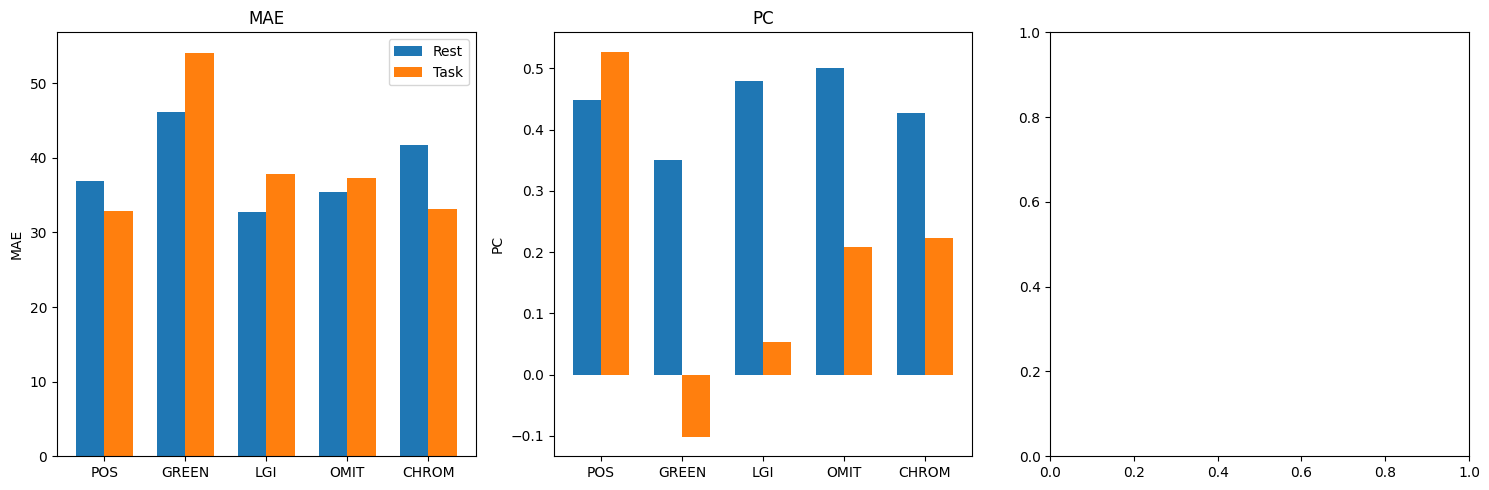

In [18]:
metrics = ["MAE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_sdnn[eval_df_sdnn["Condition"]=="Rest"][metric]
    task_vals = eval_df_sdnn[eval_df_sdnn["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 50.89      | 83.41       | 0.4546    | 70.89      | 95.17       | 0.2672    |
| GREEN  |113.42      |127.37       | 0.6198    | 94.20      |116.28       | 0.1734    |
| LGI    | 43.35      | 66.98       | 0.6697    | 69.93      | 80.68       | 0.3106    |
| OMIT   | 43.06      | 66.51       | 0.6768    | 69.84      | 81.59       | 0.2907    |
| CHROM  | 53.64      | 70.66       | 0.5486    | 72.87      | 86.82       | -0.0077   |

**Observation**

---

- HRV adalah ukuran variasi waktu antar detak jantung, sehingga membutuhkan ketelitian waktu yang lebih tinggi dibandingkan hanya menghitung rata-rata detak jantung (HR).

- Dalam evaluasi, HRV (misal SDNN) menunjukkan seberapa besar fluktuasi interval antar detak, bukan hanya jumlah detak per menit. Oleh karena itu, kualitas sinyal dan akurasi deteksi puncak sangat penting agar hasil HRV

- Pengukuran HRV seperti ini biasanya menggunakan metode kontak (EKG / PPG) yang memiliki error yang lebih rendah (MAE < 10ms) yang cocok dipakai.

- rPPG sebagai metode kontak tentu akan menghadapi error tambahan seperti delay, noise, dan aftifak gerakan. Penelitian sebelumnya berfokus pada pengukuran HRV melaporkan error SDNN / RMSSD 10 - 40 ms (Perbedaan dengan metode kontak PPG) [[1]](https://www.mdpi.com/2306-5354/10/7/851)[[2]](https://arxiv.org/pdf/2305.04161). Penggunaan korelasi (PC) juga digunakan untuk menilai konsistensi pengukuran SDNN ini.

- Pada kondisi istirahat, sama seperti pengukuran detak jantung, beberapa metode rPPG masih dapat mencapai korelasi moderat (PC > 0.6), meskipun MAE relatif tinggi (> 30–40 ms). Hal ini menunjukan rPPG dapat melakukan pengukuran HRV meskipun cederung overestimasi (dengan error yang relatif tinggi).

- Kondisi tugas/mental load: performa memburuk lebih jauh (MAE/RMSE meningkat, PC < 0.3), sehingga estimasi HRV tidak konsisten dengan referensi kontak. Penurunan performa ini disebabkan oleh gerakan wajah, ekspresi dan pencahayaan yang lebih bervariasi sama seperti pengukuran HR

- Kesimpulan: saat ini, rPPG belum cukup andal untuk mengukur nilai absolut HRV (seperti SDNN) di berbagai kondisi. Namun, pada skenario minim gerakan, rPPG masih bisa digunakan untuk memantau tren relatif (apakah HRV naik/turun) dibandingkan ground truth. Untuk mencapai presisi yang mendekati metode kontak, diperlukan pendekatan rekonstruksi sinyal yang lebih canggih 

- Namun secara general rPPG masih belum bisa untuk menangkap detail variabilitas detak jantung yang membutuhkan presisi tingkat lanjut serta reliabilitas yang masih kurang (Pearson Corr yang lemah)

#### Ekstraksi HRV (RMSSD)

---

In [19]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) RMSSD
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["RMSSD"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) RMSSD
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["RMSSD"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_rmssd = pd.DataFrame(rows, columns=columns)
print("RMSSD (Satuan: ms)")
df_rmssd

RMSSD (Satuan: ms)


Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   44  108    70   87   86    88  182  160   216  147  164   142
1      s42   82  121   147  145  147   186  142  194   200  184  213   190
2      s43   34  128   140  117  117   120  113  165   207  176  190   158
3      s44   88  173   146  147  148   166  146  193   215  169  170   180
4      s45   94  148   122  150  150   173  112  165   222  199  196   199
5      s46   58  101    61   72   72   162   80  131   161  128  131   148
6      s47   60  113   109   82   82    93  198  183   249  128  163   131
7      s48  220  120   133  105  105   157  178  179   215  177  178   190
8      s49   37   97    66   63   63    59  191  198   201  189  197   179
9      s50   20  131   172  121  120   120   51  119   229  103  103    91
10     s51   79  111   124   93   92   155  144  165   252  153  153   184
11     s52   94  137   137  133  132   126  172  190   216  162  166   183
12     s53  147  121    92   83   83    94  178  157   209  141  142   189
13     s54  100  141   251  112  113   121   81  165   197  173  185   183
14     s55   99  277   254  236  216   274   85  174   193  183  183   201
15     s56  188  193   197  202  200   219  171  170   162  209  212   118

#### Evaluasi RMSSD (MAE, RMSE dan PC)

---

- **MAE** dan **RMSE** digunakan untuk mengukur seberapa besar perbedaan nilai RMSSD antara hasil estimasi rPPG dan referensi PPG.
- **PC (Pearson Correlation)** digunakan untuk melihat tren atau korelasi antara hasil pengukuran RMSSD dari rPPG dan PPG.

In [20]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_rmssd[(cond, "GT")]  # ground truth for this condition
    for method in methods:
        row=[method]
        pred = df_rmssd[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            # "RMSE": rmse,
            "PC": pc
        })

eval_df_rmssd = pd.DataFrame(eval_results)
eval_df_rmssd

,Condition,Method,MAE,PC
0,Rest,POS,64.2500,0.279947
1,Rest,GREEN,66.3125,0.262214
2,Rest,LGI,53.8750,0.323067
3,Rest,OMIT,52.5000,0.339160
4,Rest,CHROM,68.8125,0.399685
5,Task,POS,37.6250,0.640120
6,Task,GREEN,71.1250,0.218448
7,Task,LGI,44.1875,0.208801
8,Task,OMIT,44.5000,0.323042
9,Task,CHROM,49.1250,0.125881


**Visualisasi Hasil MAE, RMSE dan PC**

---

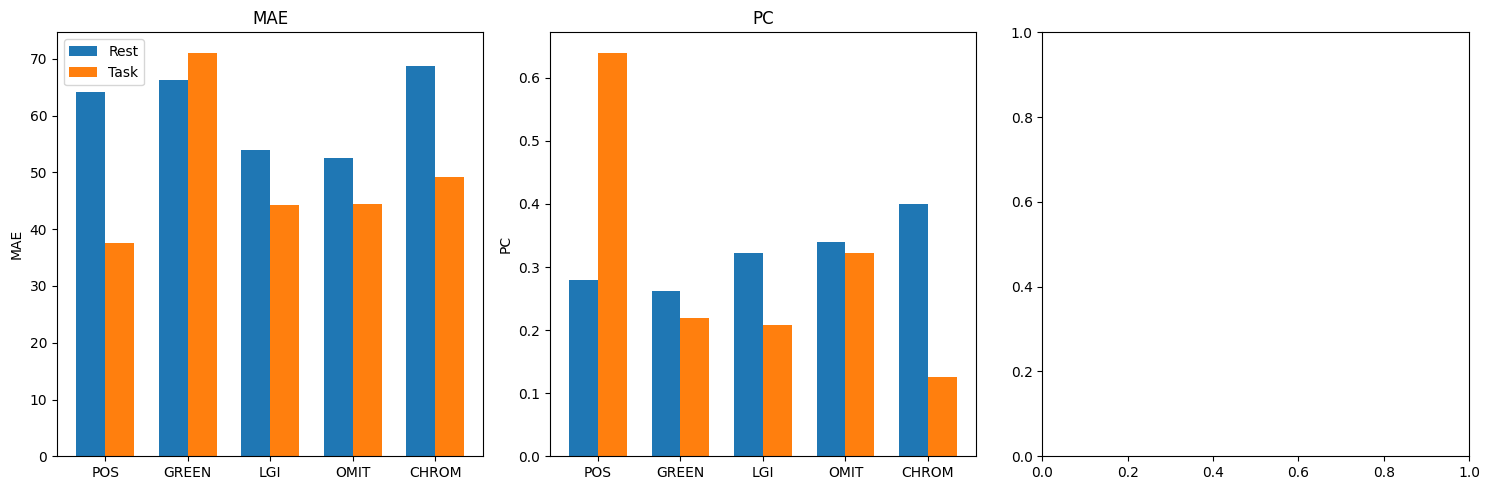

In [21]:
metrics = ["MAE", "PC"]
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
x = range(len(methods))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    rest_vals = eval_df_rmssd[eval_df_rmssd["Condition"]=="Rest"][metric]
    task_vals = eval_df_rmssd[eval_df_rmssd["Condition"]=="Task"][metric]
    ax.bar([i-width/2 for i in x], rest_vals, width, label="Rest")
    ax.bar([i+width/2 for i in x], task_vals, width, label="Task")
    ax.set_xticks(x)
    ax.set_xticklabels(methods)
    ax.set_ylabel(metric)
    ax.set_title(metric)
    if idx == 0:
        ax.legend()
plt.tight_layout()
plt.show()

| Method | MAE (Rest) | RMSE (Rest) | PC (Rest) | MAE (Task) | RMSE (Task) | PC (Task) |
|--------|------------|-------------|-----------|------------|-------------|-----------|
| POS    | 63.88      |104.86       | 0.5589    | 99.94      |130.87       | 0.2401    |
| GREEN  |159.25      |180.08       | 0.6639    |133.81      |160.21       | 0.0719    |
| LGI    | 51.94      | 80.50       | 0.7389    | 93.94      |109.39       | 0.3029    |
| OMIT   | 52.69      | 79.93       | 0.7521    | 94.13      |110.00       | 0.3005    |
| CHROM  | 74.00      | 90.42       | 0.5858    |106.00      |120.75       | -0.1035   |

**Observation**

---

- RMSSD adalah metrik HRV yang mengukur variasi jeda waktu antar detak jantung. Seperti SDNN, RMSSD membutuhkan ketelitian waktu tinggi karena fokusnya pada perubahan waktu antar detak, bukan hanya jumlah detak.
- Pada kondisi tugas mental, performa rPPG menurun, baik dari sisi error maupun konsistensi pola (Pearson Correlation).
- Secara umum, rPPG kurang cocok untuk mengukur HRV secara non-kontak di berbagai skenario karena sangat sensitif terhadap gerakan dan pencahayaan, sehingga presisi hasil HRV sulit

## Analisis Overall Score

In [22]:
# SIMPLIFIED COMPREHENSIVE RANKING ANALYSIS
print("="*80)
print("COMPREHENSIVE METHOD RANKING ANALYSIS")
print("="*80)

# Step 1: Calculate average metrics across conditions for each physiological metric
def calculate_metric_ranking(eval_df, metric_name):
    """Calculate ranking for a single physiological metric (HR, SDNN, or RMSSD)"""
    
    # Pivot to get Rest and Task values
    pivot = eval_df.pivot_table(index='Method', columns='Condition', values=['MAE', 'PC'])
    
    # Calculate averages across conditions
    mae_avg = (pivot[('MAE', 'Rest')] + pivot[('MAE', 'Task')]) / 2
    pc_avg = (pivot[('PC', 'Rest')] + pivot[('PC', 'Task')]) / 2
    
    # Rank metrics (1 = best)
    mae_rank = mae_avg.rank(ascending=True)   # Lower MAE is better
    pc_rank = pc_avg.rank(ascending=False)    # Higher PC is better
    
    # Calculate average rank for this metric
    metric_avg_rank = (mae_rank + pc_rank) / 2
    
    print(f"\n{metric_name.upper()} RANKING:")
    print("-" * 50)
    print(f"{'Method':<8} {'MAE_avg':<8} {'Rank':<6} {'PC_avg':<8} {'Rank':<6} {'Avg_Rank':<8}")
    print("-" * 50)
    
    # Sort by average rank and display
    sorted_methods = metric_avg_rank.sort_values()
    for method in sorted_methods.index:
        star = " ★" if method == sorted_methods.index[0] else ""
        print(f"{method:<8} {mae_avg[method]:<8.2f} {mae_rank[method]:<6.0f} {pc_avg[method]:<8.3f} {pc_rank[method]:<6.0f} {sorted_methods[method]:<8.2f}{star}")
    
    return metric_avg_rank

# Step 2: Calculate rankings for each physiological metric
hr_ranks = calculate_metric_ranking(eval_df_hr, "HR")
sdnn_ranks = calculate_metric_ranking(eval_df_sdnn, "SDNN") 
rmssd_ranks = calculate_metric_ranking(eval_df_rmssd, "RMSSD")

# Step 3: Calculate final overall ranking
print(f"\n{'='*80}")
print("FINAL OVERALL RANKING")
print("="*80)

methods = hr_ranks.index.tolist()
final_ranks = {}

for method in methods:
    # Average of the three metric rankings
    overall_rank = (hr_ranks[method] + sdnn_ranks[method] + rmssd_ranks[method]) / 3
    final_ranks[method] = overall_rank

# Sort by final rank
final_ranking = sorted(final_ranks.items(), key=lambda x: x[1])

print(f"{'Method':<8} {'HR_Rank':<8} {'SDNN_Rank':<10} {'RMSSD_Rank':<11} {'Overall_Rank':<12}")
print("-" * 60)

for i, (method, overall_rank) in enumerate(final_ranking):
    star = " ★★★" if i == 0 else ""
    print(f"{method:<8} {hr_ranks[method]:<8.2f} {sdnn_ranks[method]:<10.2f} {rmssd_ranks[method]:<11.2f} {overall_rank:<12.2f}{star}")

print(f"\nFINAL CALCULATION:")
print("-" * 40)
for method, overall_rank in final_ranking:
    print(f"{method}: ({hr_ranks[method]:.2f} + {sdnn_ranks[method]:.2f} + {rmssd_ranks[method]:.2f}) / 3 = {overall_rank:.2f}")

winner = final_ranking[0][0]
print(f"\n🏆 WINNER: {winner} (Overall Rank = {final_ranking[0][1]:.2f})")

COMPREHENSIVE METHOD RANKING ANALYSIS

HR RANKING:
--------------------------------------------------
Method   MAE_avg  Rank   PC_avg   Rank   Avg_Rank
--------------------------------------------------
POS      5.44     1      0.724    1      1.00     ★
CHROM    5.53     2      0.701    2      2.00    
OMIT     5.88     4      0.683    3      3.50    
LGI      5.78     3      0.679    4      3.50    
GREEN    12.41    5      0.472    5      5.00    

SDNN RANKING:
--------------------------------------------------
Method   MAE_avg  Rank   PC_avg   Rank   Avg_Rank
--------------------------------------------------
POS      34.88    1      0.487    1      1.00     ★
OMIT     36.31    3      0.354    2      2.50    
LGI      35.34    2      0.266    4      3.00    
CHROM    37.44    4      0.326    3      3.50    
GREEN    50.16    5      0.124    5      5.00    

RMSSD RANKING:
--------------------------------------------------
Method   MAE_avg  Rank   PC_avg   Rank   Avg_Rank
---------

### Overall Checks: Visualisasi Hasil MAE, RMSE, dan PC

---

Evaluasi awal dilakukan untuk menilai sejauh mana metode rPPG mampu merekonstruksi sinyal fisiologis dibandingkan sinyal referensi PPG. Penilaian dilakukan pada dua skenario (Rest dan Task) dengan tiga metrik utama: HR, SDNN, dan RMSSD. Setiap metode rPPG dievaluasi menggunakan indikator statistik (MAE, RMSE, dan Pearson Correlation).

Hasil evaluasi ini menjadi dasar untuk:
1. Menentukan metode rPPG yang relatif paling konsisten pada kedua skenario.  
2. Mengidentifikasi metrik fisiologis yang lebih stabil untuk digunakan pada tahap analisis berikutnya.  

Secara umum, **HR menunjukkan kecenderungan lebih reliabel** dibanding SDNN dan RMSSD, dengan performa lebih baik pada MAE, RMSE, dan PC. Di antara metode rPPG, **POS dan CHROM tampil lebih konsisten terutama pada estimasi HR**, meskipun performa estimasi HRV masih bervariasi dan dari hasil pengukuran, error yang dihasilkan masih cukup tinggi untuk dapat digunakan sebagai alternatif.

Berdasarkan hal ini, analisis selanjutnya difokuskan pada **HR** sebagai metrik utama. Fokus ini tidak hanya karena keunggulan teknis (error lebih rendah), tetapi juga karena HR lebih relevan sebagai indikator fisiologis terhadap peningkatan beban mental. Dengan demikian, tahap berikutnya akan memvisualisasikan perbedaan antara kondisi Rest dan Task pada level kelompok maupun individu.


### Overall Checks: Visualisasi Hasil MAE, RMSE, dan PC

---

Evaluasi awal dilakukan untuk menilai sejauh mana metode rPPG mampu merekonstruksi sinyal fisiologis dibandingkan sinyal referensi PPG. Penilaian dilakukan pada dua skenario (Rest dan Task) dengan tiga metrik utama: HR, SDNN, dan RMSSD. Setiap metode rPPG dievaluasi menggunakan indikator statistik (MAE, RMSE, dan Pearson Correlation).

Hasil evaluasi ini menjadi dasar untuk:
1. Menentukan metode rPPG yang relatif paling konsisten pada kedua skenario.  
2. Mengidentifikasi metrik fisiologis yang lebih stabil untuk digunakan pada tahap analisis berikutnya.  

Secara umum, **HR menunjukkan kecenderungan lebih reliabel** dibanding SDNN dan RMSSD, dengan performa lebih baik pada MAE, RMSE, dan PC. Di antara metode rPPG, **POS dan CHROM tampil lebih konsisten terutama pada estimasi HR**, meskipun performa estimasi HRV masih bervariasi dan dari hasil pengukuran, error yang dihasilkan masih cukup tinggi untuk dapat digunakan sebagai alternatif.

Berdasarkan hal ini, analisis selanjutnya difokuskan pada **HR** sebagai metrik utama. Fokus ini tidak hanya karena keunggulan teknis (error lebih rendah), tetapi juga karena HR lebih relevan sebagai indikator fisiologis terhadap peningkatan beban mental. Dengan demikian, tahap berikutnya akan memvisualisasikan perbedaan antara kondisi Rest dan Task pada level kelompok maupun individu.


# Robustness Formula

### Evaluation Metrics

For method comparison, we employed two complementary metrics:

1. **Mean Absolute Error (MAE)**: Measures prediction accuracy by calculating the average absolute difference between rPPG estimates and PPG ground truth values.

2. **Pearson Correlation (PC)**: Evaluates how well rPPG methods capture the physiological trend patterns compared to ground truth, regardless of absolute value differences.

We focused on MAE and PC rather than including RMSE for the following reasons:
- **Reduced redundancy**: MAE and RMSE both measure prediction error, with RMSE being more sensitive to outliers. For ranking purposes, they provide similar method ordering.
- **Complementary information**: MAE quantifies accuracy while PC assesses pattern consistency, providing distinct evaluation perspectives.
- **Interpretability**: MAE offers direct clinical interpretation (error in bpm/ms), while PC indicates trend-following capability.
- **Simplicity**: A two-metric approach reduces complexity while maintaining comprehensive evaluation coverage.

In [23]:
# ...existing code...

# Create HR ranking based on average performance across conditions
print("=== HR Method Ranking Analysis ===")

# Pivot the evaluation results for easier calculation
hr_pivot = eval_df_hr.pivot_table(index='Method', columns='Condition', values=['MAE', 'RMSE', 'PC'])

# Calculate averages across both conditions
hr_ranking = pd.DataFrame({
    'Method': hr_pivot.index,
    'MAE_avg': (hr_pivot[('MAE', 'Rest')] + hr_pivot[('MAE', 'Task')]) / 2,
    # 'RMSE_avg': (hr_pivot[('RMSE', 'Rest')] + hr_pivot[('RMSE', 'Task')]) / 2,
    'PC_avg': (hr_pivot[('PC', 'Rest')] + hr_pivot[('PC', 'Task')]) / 2
})

# Rank each metric (1 = best)
hr_ranking['MAE_rank'] = hr_ranking['MAE_avg'].rank(ascending=True)  # Lower MAE is better
# hr_ranking['RMSE_rank'] = hr_ranking['RMSE_avg'].rank(ascending=True)  # Lower RMSE is better  
hr_ranking['PC_rank'] = hr_ranking['PC_avg'].rank(ascending=False)  # Higher PC is better

# Calculate average rank (lower is better)
hr_ranking['Avg_rank'] = (hr_ranking['MAE_rank'] + hr_ranking['PC_rank']) / 2

# Sort by average rank (best to worst)
hr_ranking_sorted = hr_ranking.sort_values('Avg_rank', ascending=True)

print("CONDITION: HR Evaluation")
print("="*80)
print(f"{'Method':<8} {'MAE_avg':<8} {'→rank':<6} {'RMSE_avg':<9} {'→rank':<6} {'PC_avg':<8} {'→rank':<6} {'|':<2} {'Avg_rank':<8}")
print("-" * 80)

for idx, (method, row) in enumerate(hr_ranking_sorted.iterrows()):
    star = " ★" if idx == 0 else "  "
    print(f"{method:<8} {row['MAE_avg']:<8.2f} {row['MAE_rank']:<6.0f} {'':<9} {'':<6} {row['PC_avg']:<8.3f} {row['PC_rank']:<6.0f} {'|':<2} {row['Avg_rank']:<8.2f}{star}")

print(f"\n★ Best overall method: {hr_ranking_sorted.index[0]}")


# ...existing code...

=== HR Method Ranking Analysis ===
CONDITION: HR Evaluation
Method   MAE_avg  →rank  RMSE_avg  →rank  PC_avg   →rank  |  Avg_rank
--------------------------------------------------------------------------------
POS      5.44     1                       0.724    1      |  1.00     ★
CHROM    5.53     2                       0.701    2      |  2.00      
OMIT     5.88     4                       0.683    3      |  3.50      
LGI      5.78     3                       0.679    4      |  3.50      
GREEN    12.41    5                       0.472    5      |  5.00      

★ Best overall method: POS


In [24]:
# ...existing code...

# Create HR ranking based on average performance across conditions
print("=== HR Method Ranking Analysis ===")

# Pivot the evaluation results for easier calculation
hr_pivot = eval_df_hr.pivot_table(index='Method', columns='Condition', values=['MAE', 'PC'])

# Calculate averages across both conditions
hr_ranking = pd.DataFrame({
    'Method': hr_pivot.index,
    'MAE_avg': (hr_pivot[('MAE', 'Rest')] + hr_pivot[('MAE', 'Task')]) / 2,
    'PC_avg': (hr_pivot[('PC', 'Rest')] + hr_pivot[('PC', 'Task')]) / 2
})

# Rank each metric (1 = best)
hr_ranking['MAE_rank'] = hr_ranking['MAE_avg'].rank(ascending=True)  # Lower MAE is better
hr_ranking['PC_rank'] = hr_ranking['PC_avg'].rank(ascending=False)  # Higher PC is better

# Calculate average rank (lower is better)
hr_ranking['Avg_rank'] = (hr_ranking['MAE_rank'] + hr_ranking['PC_rank']) / 2

# Sort by average rank (best to worst)
hr_ranking_sorted = hr_ranking.sort_values('Avg_rank', ascending=True)

print("CONDITION: HR Evaluation")
print("="*80)
print(f"{'Method':<8} {'MAE_avg':<8} {'→rank':<6} {'PC_avg':<8} {'→rank':<6} {'|':<2} {'Avg_rank':<8}")
print("-" * 80)

for idx, (method, row) in enumerate(hr_ranking_sorted.iterrows()):
    star = " ★" if idx == 0 else "  "
    print(f"{method:<8} {row['MAE_avg']:<8.2f} {row['MAE_rank']:<6.0f} {row['PC_avg']:<8.3f} {row['PC_rank']:<6.0f} {'|':<2} {row['Avg_rank']:<8.2f}{star}")

print(f"\n★ Best overall HR method: {hr_ranking_sorted.index[0]}")

# Create SDNN ranking based on average performance across conditions
print("\n=== SDNN Method Ranking Analysis ===")

# Pivot the SDNN evaluation results
sdnn_pivot = eval_df_sdnn.pivot_table(index='Method', columns='Condition', values=['MAE', 'PC'])

# Calculate averages across both conditions
sdnn_ranking = pd.DataFrame({
    'Method': sdnn_pivot.index,
    'MAE_avg': (sdnn_pivot[('MAE', 'Rest')] + sdnn_pivot[('MAE', 'Task')]) / 2,
    'PC_avg': (sdnn_pivot[('PC', 'Rest')] + sdnn_pivot[('PC', 'Task')]) / 2
})

# Rank each metric (1 = best)
sdnn_ranking['MAE_rank'] = sdnn_ranking['MAE_avg'].rank(ascending=True)  # Lower MAE is better
sdnn_ranking['PC_rank'] = sdnn_ranking['PC_avg'].rank(ascending=False)  # Higher PC is better

# Calculate average rank (lower is better)
sdnn_ranking['Avg_rank'] = (sdnn_ranking['MAE_rank'] + sdnn_ranking['PC_rank']) / 2

# Sort by average rank (best to worst)
sdnn_ranking_sorted = sdnn_ranking.sort_values('Avg_rank', ascending=True)

print("CONDITION: SDNN Evaluation")
print("="*80)
print(f"{'Method':<8} {'MAE_avg':<8} {'→rank':<6} {'PC_avg':<8} {'→rank':<6} {'|':<2} {'Avg_rank':<8}")
print("-" * 80)

for idx, (method, row) in enumerate(sdnn_ranking_sorted.iterrows()):
    star = " ★" if idx == 0 else "  "
    print(f"{method:<8} {row['MAE_avg']:<8.2f} {row['MAE_rank']:<6.0f} {row['PC_avg']:<8.3f} {row['PC_rank']:<6.0f} {'|':<2} {row['Avg_rank']:<8.2f}{star}")

print(f"\n★ Best overall SDNN method: {sdnn_ranking_sorted.index[0]}")

# Create RMSSD ranking based on average performance across conditions
print("\n=== RMSSD Method Ranking Analysis ===")

# Pivot the RMSSD evaluation results
rmssd_pivot = eval_df_rmssd.pivot_table(index='Method', columns='Condition', values=['MAE', 'PC'])

# Calculate averages across both conditions
rmssd_ranking = pd.DataFrame({
    'Method': rmssd_pivot.index,
    'MAE_avg': (rmssd_pivot[('MAE', 'Rest')] + rmssd_pivot[('MAE', 'Task')]) / 2,
    'PC_avg': (rmssd_pivot[('PC', 'Rest')] + rmssd_pivot[('PC', 'Task')]) / 2
})

# Rank each metric (1 = best)
rmssd_ranking['MAE_rank'] = rmssd_ranking['MAE_avg'].rank(ascending=True)  # Lower MAE is better
rmssd_ranking['PC_rank'] = rmssd_ranking['PC_avg'].rank(ascending=False)  # Higher PC is better

# Calculate average rank (lower is better)
rmssd_ranking['Avg_rank'] = (rmssd_ranking['MAE_rank'] + rmssd_ranking['PC_rank']) / 2

# Sort by average rank (best to worst)
rmssd_ranking_sorted = rmssd_ranking.sort_values('Avg_rank', ascending=True)

print("CONDITION: RMSSD Evaluation")
print("="*80)
print(f"{'Method':<8} {'MAE_avg':<8} {'→rank':<6} {'PC_avg':<8} {'→rank':<6} {'|':<2} {'Avg_rank':<8}")
print("-" * 80)

for idx, (method, row) in enumerate(rmssd_ranking_sorted.iterrows()):
    star = " ★" if idx == 0 else "  "
    print(f"{method:<8} {row['MAE_avg']:<8.2f} {row['MAE_rank']:<6.0f} {row['PC_avg']:<8.3f} {row['PC_rank']:<6.0f} {'|':<2} {row['Avg_rank']:<8.2f}{star}")

print(f"\n★ Best overall RMSSD method: {rmssd_ranking_sorted.index[0]}")

# FINAL COMPREHENSIVE RANKING - Combine all metrics (MAE + PC only)
print("\n" + "="*100)
print("FINAL COMPREHENSIVE RANKING - ALL METRICS COMBINED (MAE + PC)")
print("="*100)

# Create a comprehensive ranking DataFrame with all ranks
methods = hr_ranking_sorted.index.tolist()

# Collect all ranks for each method
comprehensive_data = []
for method in methods:
    # Get HR ranks (MAE + PC only)
    hr_mae_rank = hr_ranking_sorted.loc[method, 'MAE_rank']
    hr_pc_rank = hr_ranking_sorted.loc[method, 'PC_rank']
    
    # Get SDNN ranks (MAE + PC only)
    sdnn_mae_rank = sdnn_ranking_sorted.loc[method, 'MAE_rank']
    sdnn_pc_rank = sdnn_ranking_sorted.loc[method, 'PC_rank']
    
    # Get RMSSD ranks (MAE + PC only)
    rmssd_mae_rank = rmssd_ranking_sorted.loc[method, 'MAE_rank']
    rmssd_pc_rank = rmssd_ranking_sorted.loc[method, 'PC_rank']
    
    # Calculate final average rank across all 6 individual ranks
    final_avg_rank = (hr_mae_rank + hr_pc_rank + 
                     sdnn_mae_rank + sdnn_pc_rank +
                     rmssd_mae_rank + rmssd_pc_rank) / 6
    
    comprehensive_data.append({
        'Method': method,
        'HR_MAE_rank': hr_mae_rank,
        'HR_PC_rank': hr_pc_rank,
        'SDNN_MAE_rank': sdnn_mae_rank,
        'SDNN_PC_rank': sdnn_pc_rank,
        'RMSSD_MAE_rank': rmssd_mae_rank,
        'RMSSD_PC_rank': rmssd_pc_rank,
        'Final_Avg_Rank': final_avg_rank
    })

# Create DataFrame and sort by final average rank
final_ranking = pd.DataFrame(comprehensive_data).sort_values('Final_Avg_Rank', ascending=True)

print(f"{'Method':<8} HR(MAE,PC) SDNN(MAE,PC) RMSSD(MAE,PC) {'Final_Avg':<10}")
print("-" * 80)

for idx, row in final_ranking.iterrows():
    star = " ★★★" if idx == 0 else "    "
    hr_ranks = f"({row['HR_MAE_rank']:.0f},{row['HR_PC_rank']:.0f})"
    sdnn_ranks = f"({row['SDNN_MAE_rank']:.0f},{row['SDNN_PC_rank']:.0f})"
    rmssd_ranks = f"({row['RMSSD_MAE_rank']:.0f},{row['RMSSD_PC_rank']:.0f})"
    
    print(f"{row['Method']:<8} {hr_ranks:<10} {sdnn_ranks:<12} {rmssd_ranks:<13} {row['Final_Avg_Rank']:<10.2f}{star}")

print(f"\nFINAL OVERALL AVERAGE RANK:")
print("-" * 60)

for idx, row in final_ranking.iterrows():
    all_ranks = [row['HR_MAE_rank'], row['HR_PC_rank'],
                row['SDNN_MAE_rank'], row['SDNN_PC_rank'],
                row['RMSSD_MAE_rank'], row['RMSSD_PC_rank']]
    
    rank_str = " + ".join([f"{r:.2f}" for r in all_ranks])
    print(f"{row['Method']}: ({rank_str}) / 6 = {row['Final_Avg_Rank']:.2f}")

winner = final_ranking.iloc[0]
print(f"\nWINNER: {winner['Method']} (lowest average rank = {winner['Final_Avg_Rank']:.2f}) ★★★")

# Summary table of individual metric rankings
print("\n=== INDIVIDUAL METRIC RANKING SUMMARY ===")
print("="*50)
print(f"{'Metric':<8} {'Best Method':<12} {'Avg Rank':<10}")
print("-" * 50)
print(f"{'HR':<8} {hr_ranking_sorted.index[0]:<12} {hr_ranking_sorted['Avg_rank'].iloc[0]:<10.2f}")
print(f"{'SDNN':<8} {sdnn_ranking_sorted.index[0]:<12} {sdnn_ranking_sorted['Avg_rank'].iloc[0]:<10.2f}")
print(f"{'RMSSD':<8} {rmssd_ranking_sorted.index[0]:<12} {rmssd_ranking_sorted['Avg_rank'].iloc[0]:<10.2f}")
print(f"{'OVERALL':<8} {winner['Method']:<12} {winner['Final_Avg_Rank']:<10.2f}")

# ...existing code...

=== HR Method Ranking Analysis ===
CONDITION: HR Evaluation
Method   MAE_avg  →rank  PC_avg   →rank  |  Avg_rank
--------------------------------------------------------------------------------
POS      5.44     1      0.724    1      |  1.00     ★
CHROM    5.53     2      0.701    2      |  2.00      
OMIT     5.88     4      0.683    3      |  3.50      
LGI      5.78     3      0.679    4      |  3.50      
GREEN    12.41    5      0.472    5      |  5.00      

★ Best overall HR method: POS

=== SDNN Method Ranking Analysis ===
CONDITION: SDNN Evaluation
Method   MAE_avg  →rank  PC_avg   →rank  |  Avg_rank
--------------------------------------------------------------------------------
POS      34.88    1      0.487    1      |  1.00     ★
OMIT     36.31    3      0.354    2      |  2.50      
LGI      35.34    2      0.266    4      |  3.00      
CHROM    37.44    4      0.326    3      |  3.50      
GREEN    50.16    5      0.124    5      |  5.00      

★ Best overall SDNN metho

## Analisis : Tugas Istirahat vs Tugas Mental

---

Karena HR (Heart Rate) merupakan satu-satunya metrik yang paling reliabel dari hasil estimasi, maka analisis selanjutnya akan difokuskan pada pengaruh kondisi Rest dan Task terhadap nilai HR.

Visualisasi berikut akan menunjukkan bagaimana perubahan HR terjadi antara kondisi istirahat (Rest) dan tugas (Task), baik pada level kelompok maupun individu.

---

### Analisis Tingkat Kelompok

Melihat pengaruh kondisi tugas terhadap peningkatan HR secara keseluruhan pada kelompok subjek.

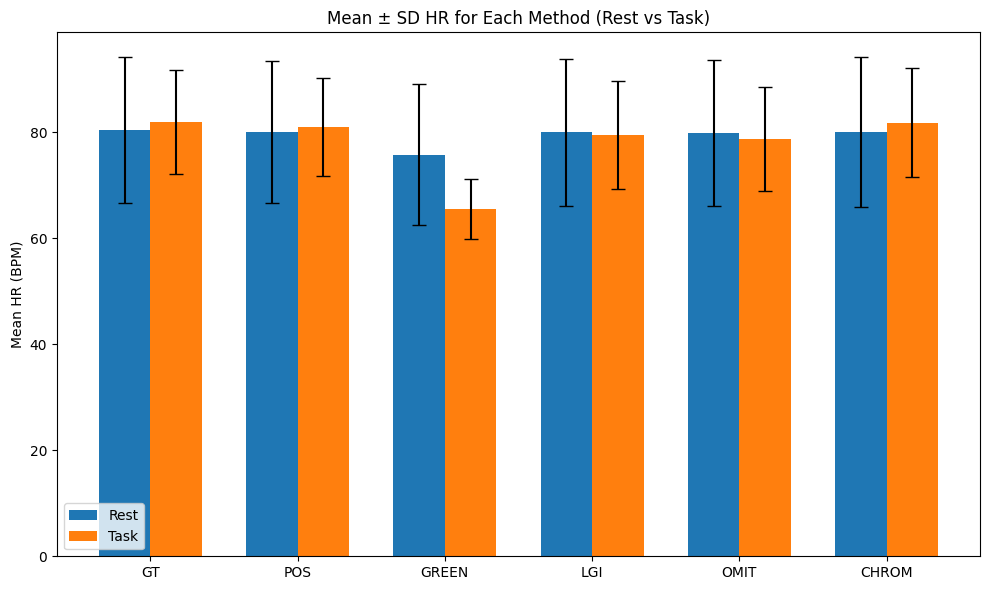

In [25]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

mean_vals = []
std_vals = []
for cond in conditions:
    for method in methods:
        vals = df_hr[(cond, method)].values
        mean_vals.append(np.mean(vals))
        std_vals.append(np.std(vals))

# Reshape for plotting
mean_vals = np.array(mean_vals).reshape(2, len(methods))
std_vals = np.array(std_vals).reshape(2, len(methods))

x = np.arange(len(methods))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
bars_rest = ax.bar(x - width/2, mean_vals[0], width, yerr=std_vals[0], capsize=5, label='Rest')
bars_task = ax.bar(x + width/2, mean_vals[1], width, yerr=std_vals[1], capsize=5, label='Task')

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Mean HR (BPM)")
ax.set_title("Mean ± SD HR for Each Method (Rest vs Task)")
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
methods = ["GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

# Calculate mean and std for each method and condition
summary = pd.DataFrame(index=methods)
for cond in conditions:
    stats = df_hr[cond].agg(["mean", "std"])
    summary[f"{cond} Mean"] = stats.loc["mean"].values
    summary[f"{cond} STD"] = stats.loc["std"].values

summary

,Rest Mean,Rest STD,Task Mean,Task STD
GT,80.3125,14.206659,81.9375,10.135540
POS,80.0000,13.856406,81.0000,9.556847
GREEN,75.7500,13.718601,65.4375,5.864796
LGI,79.9375,14.326985,79.5000,10.545141
OMIT,79.8125,14.293209,78.6875,10.143758
CHROM,79.9375,14.617199,81.7500,10.661457


**Observasi dan Analisis**

---

- Berdasarkan data rata-rata (mean) dan standar deviasi (STD) detak jantung dari metode kontak (PPG/GT), tidak ditemukan perbedaan signifikan antara kondisi istirahat (Rest) dan tugas mental (Task). Nilai rata-rata HR hampir sama (Rest: 79.44 bpm, Task: 79.25 bpm).

- Studi lebih lanjut dengan jumlah data yang lebih besar diperlukan agar efek statistik dapat terlihat lebih jelas.

- Metode rPPG cenderung menghasilkan estimasi pengukuran HR yang lebih tinggi (overestimasi) atau lebih rendah (underestimasi) dibandingkan GT, dengan rata-rata HR yang relatif tinggi pada kedua skenario.

- Karena secara statistik belum terlihat perbedaan yang jelas, analisis intrasubjek diperlukan untuk mengetahui apakah PPG dan rPPG mampu menangkap perubahan fisiologis individu saat mengalami beban mental.

### Analisis Intrasubjek

Melihat bagaimana Respons Individu terhadap Pengaruh tugas istirahat dan mental

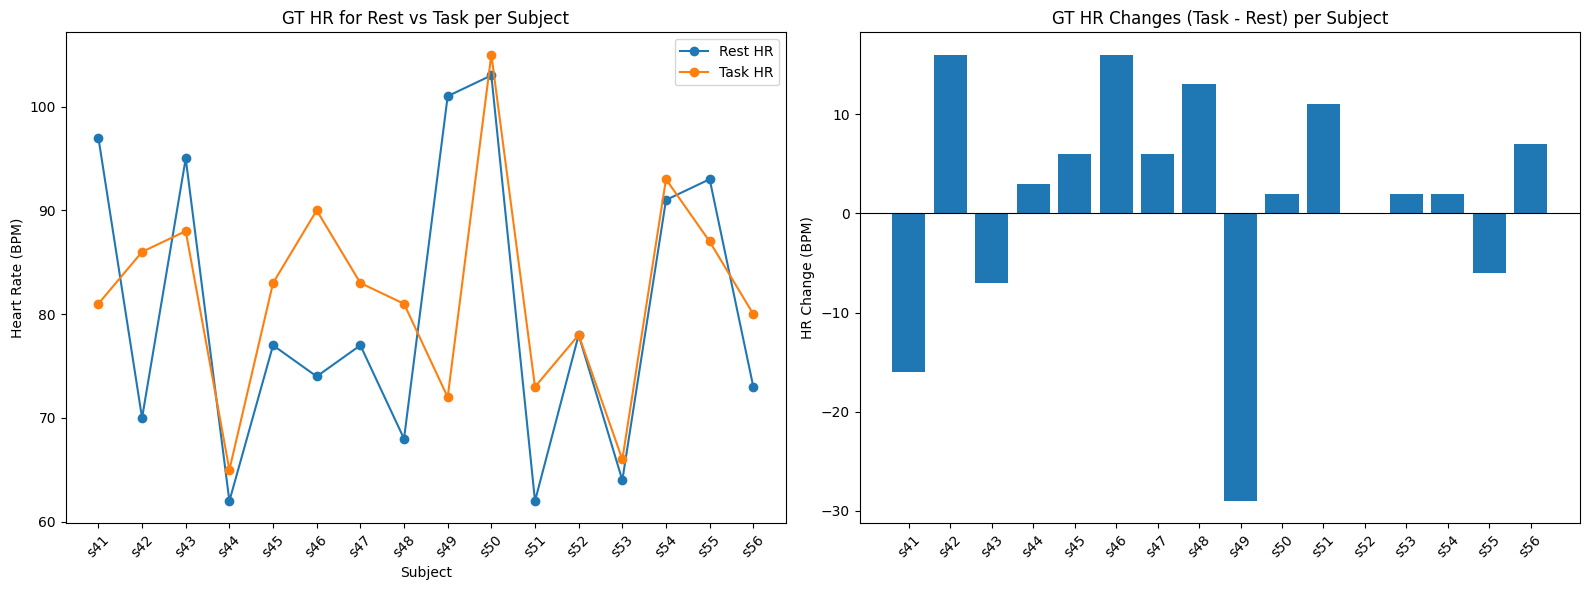

,Subject,Rest_GT,Task_GT,Delta_GT
0,s41,97,81,-16
1,s42,70,86,16
2,s43,95,88,-7
3,s44,62,65,3
4,s45,77,83,6
5,s46,74,90,16
6,s47,77,83,6
7,s48,68,81,13
8,s49,101,72,-29
9,s50,103,105,2


In [27]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "GT")].values
task_hr = df_hr[("Task", "GT")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_GT": rest_hr,
    "Task_GT": task_hr,
    "Delta_GT": delta_hr
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
axes[0].plot(df_ind["Subject"], df_ind["Rest_GT"], marker="o", label="Rest HR")
axes[0].plot(df_ind["Subject"], df_ind["Task_GT"], marker="o", label="Task HR")
axes[0].set_title("GT HR for Rest vs Task per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Heart Rate (BPM)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bar chart
axes[1].bar(df_ind["Subject"], df_ind["Delta_GT"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("GT HR Changes (Task - Rest) per Subject")
axes[1].set_ylabel("HR Change (BPM)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_GT","Task_GT","Delta_GT"]]

**Metode POS**

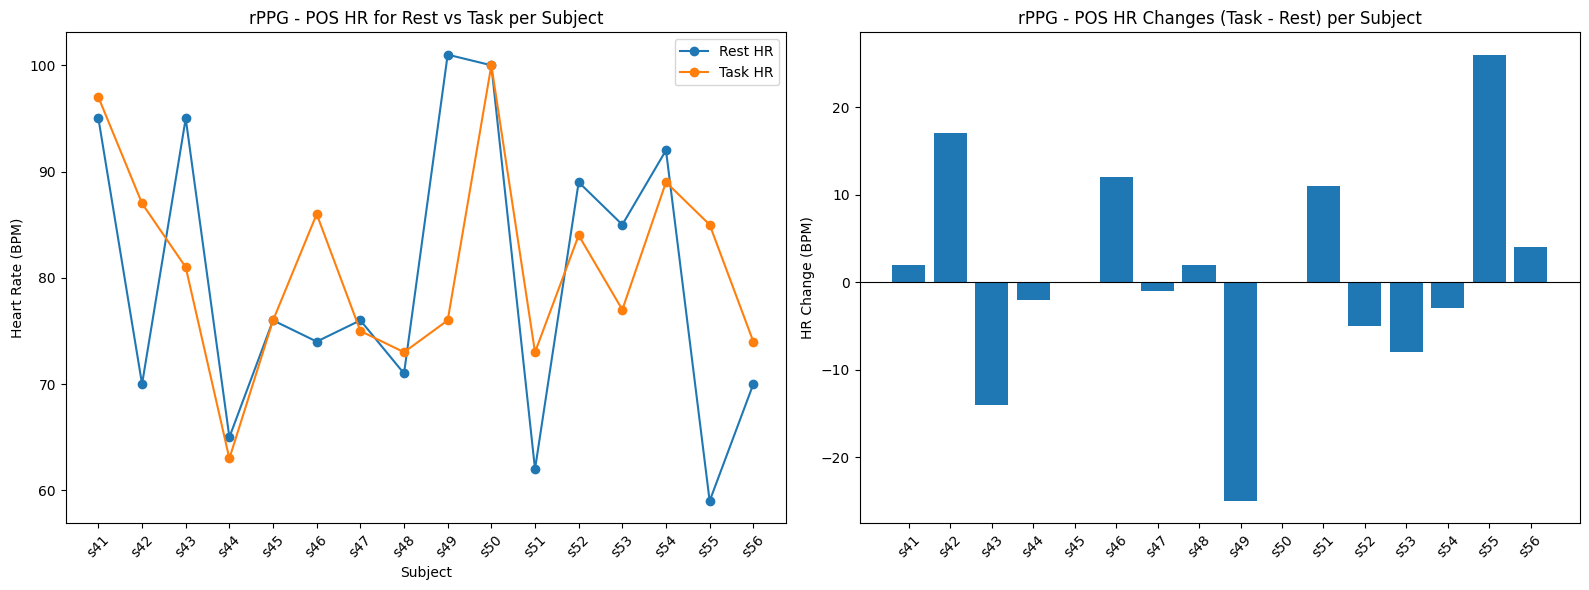

,Subject,Rest_POS,Task_POS,Delta_POS
0,s41,95,97,2
1,s42,70,87,17
2,s43,95,81,-14
3,s44,65,63,-2
4,s45,76,76,0
5,s46,74,86,12
6,s47,76,75,-1
7,s48,71,73,2
8,s49,101,76,-25
9,s50,100,100,0


In [28]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "POS")].values
task_hr = df_hr[("Task", "POS")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_POS": rest_hr,
    "Task_POS": task_hr,
    "Delta_POS": delta_hr
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
axes[0].plot(df_ind["Subject"], df_ind["Rest_POS"], marker="o", label="Rest HR")
axes[0].plot(df_ind["Subject"], df_ind["Task_POS"], marker="o", label="Task HR")
axes[0].set_title("rPPG - POS HR for Rest vs Task per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Heart Rate (BPM)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bar chart
axes[1].bar(df_ind["Subject"], df_ind["Delta_POS"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("rPPG - POS HR Changes (Task - Rest) per Subject")
axes[1].set_ylabel("HR Change (BPM)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_POS","Task_POS","Delta_POS"]]

**Metode CHROM**

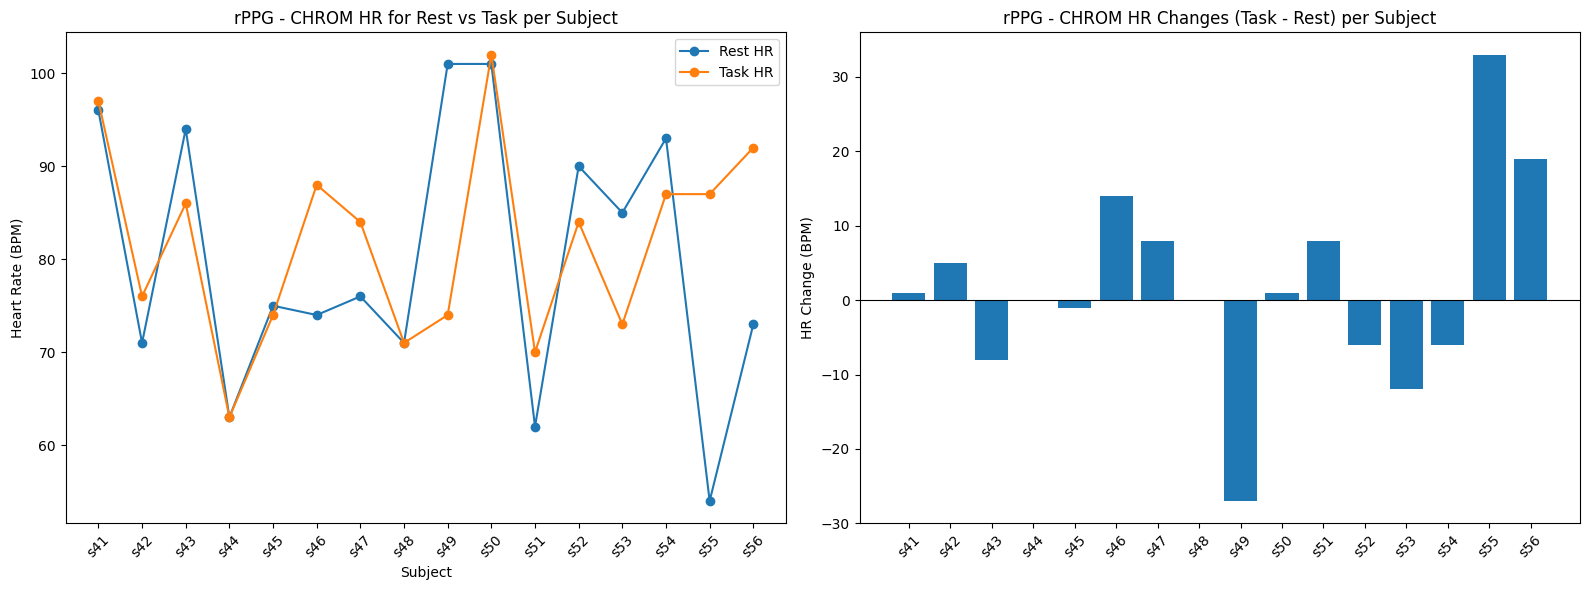

,Subject,Rest_CHROM,Task_CHROM,Delta_CHROM
0,s41,96,97,1
1,s42,71,76,5
2,s43,94,86,-8
3,s44,63,63,0
4,s45,75,74,-1
5,s46,74,88,14
6,s47,76,84,8
7,s48,71,71,0
8,s49,101,74,-27
9,s50,101,102,1


In [29]:
subjects = df_hr[("", "Subject")].values if ("", "Subject") in df_hr.columns else df_hr.index
rest_hr = df_hr[("Rest", "CHROM")].values
task_hr = df_hr[("Task", "CHROM")].values
delta_hr = task_hr - rest_hr

import pandas as pd
df_ind = pd.DataFrame({
    "Subject": subjects,
    "Rest_CHROM": rest_hr,
    "Task_CHROM": task_hr,
    "Delta_CHROM": delta_hr
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Line chart
axes[0].plot(df_ind["Subject"], df_ind["Rest_CHROM"], marker="o", label="Rest HR")
axes[0].plot(df_ind["Subject"], df_ind["Task_CHROM"], marker="o", label="Task HR")
axes[0].set_title("rPPG - CHROM HR for Rest vs Task per Subject")
axes[0].set_xlabel("Subject")
axes[0].set_ylabel("Heart Rate (BPM)")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Bar chart
axes[1].bar(df_ind["Subject"], df_ind["Delta_CHROM"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("rPPG - CHROM HR Changes (Task - Rest) per Subject")
axes[1].set_ylabel("HR Change (BPM)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

df_ind[["Subject","Rest_CHROM","Task_CHROM","Delta_CHROM"]]

### Konsistensi Pola antara GT & rPPG

- Secara individu, baik data PPG maupun rPPG saat mengukur HR (detak jantung) menunjukkan variasi respons yang berbeda ketika subjek berada dalam beban mental.

- Sebagian subjek mengalami peningkatan detak jantung, sementara yang lain mengalami penurunan, baik pada plot data HR menggunakan metode kontak (PPG) maupun non-kontak (rPPG, POS dan CHROM) yang relatif stabil terhadap tugas mental.

- Hal ini mendukung teori psikofisiologis bahwa respons individu terhadap beban mental memang bervariasi secara fisiologis, namun diperlukan data lebih banyak agar efek statistik dapat terlihat lebih

## Diskusi Keseluruhan

---

### Implikasi terhadap beban mental

Berdasarkan hasil analisis HR pada kondisi istirahat dan tugas mental, secara umum terlihat adanya kecenderungan peningkatan detak jantung saat subjek menghadapi beban kognitif, meskipun respons intrasubjek menunjukkan variasi. Temuan ini mendukung teori psikofisiologis bahwa peningkatan beban mental berkaitan dengan peningkatan aktivasi fisiologis.

Namun, karena penelitian ini melibatkan jumlah subjek yang terbatas (N = 16), generalisasi hasil masih perlu diuji pada populasi yang lebih luas dan dengan variasi tugas kognitif yang berbeda. Penelitian lanjutan juga penting untuk mengeksplorasi kombinasi metrik lain seperti HRV, agar pemahaman mengenai respons fisiologis terhadap stres kognitif menjadi lebih komprehensif.

### Keterbatasan metode rPPG

Metode rPPG menawarkan keunggulan karena mampu mengukur sinyal fisiologis hanya dengan kamera, tanpa sensor kontak langsung. Namun, penerapannya masih menghadapi beberapa keterbatasan.

Pertama, rPPG sangat sensitif terhadap pergerakan. Kondisi ideal ketika subjek benar-benar diam tidak selalu dapat dicapai, bahkan dalam lingkungan kerja yang terkontrol. Hal ini dapat memengaruhi akurasi estimasi detak jantung. Hal ini dibuktikan ketika terdapat penurunan error yang lebih tinggi ketika mengukur subjek dalam tugas mental

Kedua, rPPG memiliki keterbatasan dalam mengukur metrik psikofisiologis yang lebih kompleks seperti HRV. Estimasi HRV menuntut presisi tinggi dan stabilitas sinyal, sementara rPPG masih rentan terhadap noise, sehingga hasilnya kurang konsisten dibandingkan dengan sensor kontak langsung seperti PPG atau ECG.

### Konsep PoC

Berdasarkan hasil ini, akan dibuat sebuah PoC dengan menggunakan metode POS / CHROM karena metode ini masih cukup tahan (robust) pada dua kondisi yang berbeda sehingga cocok untuk melakukan monitoring terhadap individu.